# 📊 Advanced Exploratory Data Analysis

### 🧱 NOTEBOOK STRUCTURE

1. Setup & Data Loading
2. Target Behavior Analysis
3. Univariate Feature → Target Analysis
4. Non-Linear Relationship Analysis
5. Interaction Effects (CRITICAL)
6. Customer-Level Behavior Analysis
7. Temporal Dynamics Analysis
8. Train vs Test Distribution Shift
9. Economic Signal Exploration
10. Feature Importance Proxy Analysis
11. Key Insights → Feature Engineering Blueprint

**1. SETUP**

In [ ]:
# ======================
# Setup
# ======================
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.data_loader import load_data


set_seed = 42

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

**2. LOAD & PREPARE DATA**

In [2]:
train, test, econ = load_data()

# Fix dtypes
def fix_dtypes(df):
    df = df.copy()
    
    df["disbursement_date"] = pd.to_datetime(df["disbursement_date"])
    df["due_date"] = pd.to_datetime(df["due_date"])
    
    for col in ["country_id", "loan_type", "New_versus_Repeat"]:
        df[col] = df[col].astype("category")
    
    return df

train = fix_dtypes(train)
test = fix_dtypes(test)

# Drop leakage column
train = train.drop(columns=["Lender_portion_to_be_repaid"])
test = test.drop(columns=["Lender_portion_to_be_repaid"])

print("Data prepared ✅")

Data prepared ✅


**3. TARGET BEHAVIOUR ANALYSIS**

Target Distribution:


target
0    98.167623
1     1.832377
Name: proportion, dtype: float64

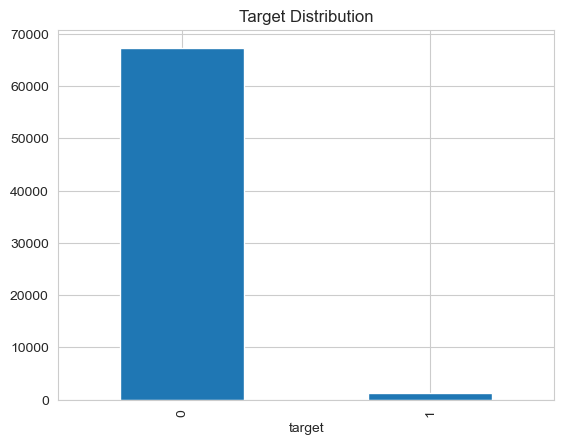

In [3]:
print("Target Distribution:")
display(train["target"].value_counts(normalize=True) * 100)

plt.figure()
train["target"].value_counts().plot(kind="bar")
plt.title("Target Distribution")
plt.show()

+ Class 0: ~98.17%
+ Class 1: ~1.83%

+ This is extreme class imbalance.

+ Standard modeling will fail:
+ Accuracy → meaningless (~98% baseline)
+ Model will predict all zeros

+ Use F1 Score (already given) ✔
+ Apply:
    + class_weight='balanced'
    + or scale_pos_weight (XGBoost/LightGBM)
    + Threshold tuning

**4. UNIVARIATE FEATURE → TARGET ANALYSIS**

4.1 Categorical Features


===== loan_type =====


,mean,count
loan_type,,
Type_20,0.833333,18
Type_12,0.500000,4
Type_17,0.454545,11
Type_2,0.388889,360
Type_21,0.166667,6
Type_6,0.122222,360
Type_4,0.117207,1203
Type_7,0.081848,2749
Type_5,0.078600,1514


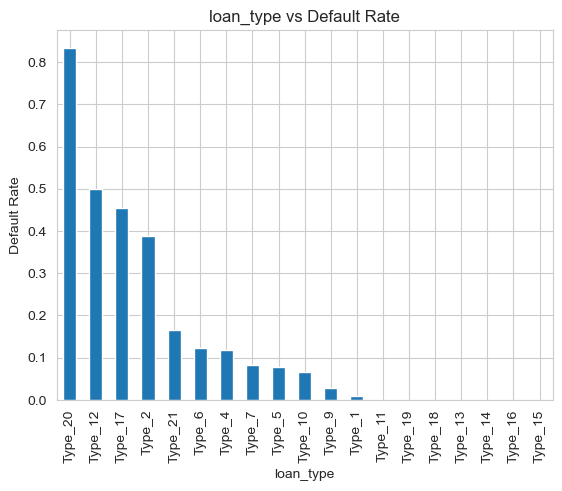


===== New_versus_Repeat =====


,mean,count
New_versus_Repeat,,
New Loan,0.199262,542
Repeat Loan,0.016884,68112


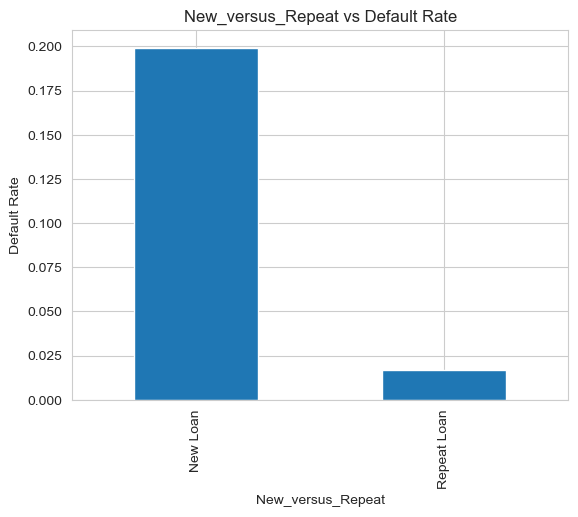

In [5]:
def plot_categorical_target(df, col):
    stats = df.groupby(col)["target"].agg(["mean", "count"]).sort_values("mean", ascending=False)
    
    display(stats.head(10))
    
    plt.figure()
    stats["mean"].plot(kind="bar")
    plt.title(f"{col} vs Default Rate")
    plt.ylabel("Default Rate")
    plt.show()


for col in ["loan_type", "New_versus_Repeat"]:
    print(f"\n===== {col} =====")
    plot_categorical_target(train, col)

+ Some types → very high default rates (e.g., Type_20 = 83%); BUT counts are extremely small

+ This is high-variance noise, not signal

Example:

    - Type_12 → only 4 samples

    - Type_20 → only 18 samples

If you encode directly → model will:

    - Overfit rare categories

    - Learn false patterns

Correct approach:

    Group rare categories: if count < threshold: loan_type = "rare"

+ Loan type DOES matter; But only for frequent categories

+ New Loan → ~19.9% default
+ Repeat Loan → ~1.7% default
+ This is one of the strongest signals in the dataset
+ Trust / credit history proxy
+ Repeat customers = safer
+ Feature engineering: is_new_customer = (New_versus_Repeat == "New Loan").astype(int)

+ Combine with: loan count + past defaults

4.2 Numerical Features

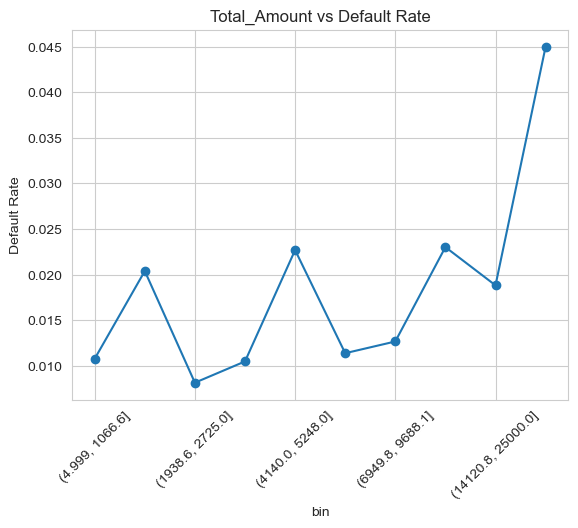

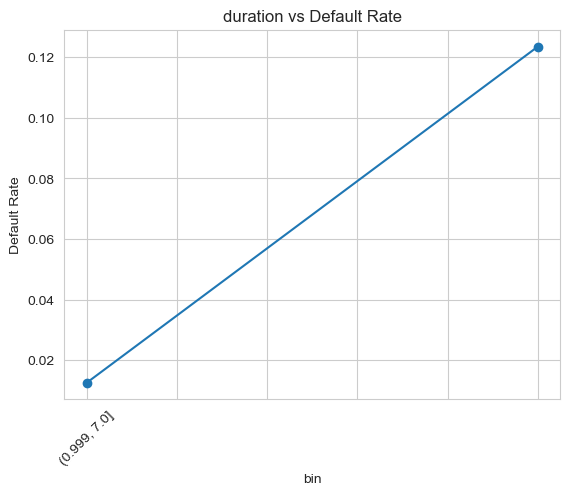

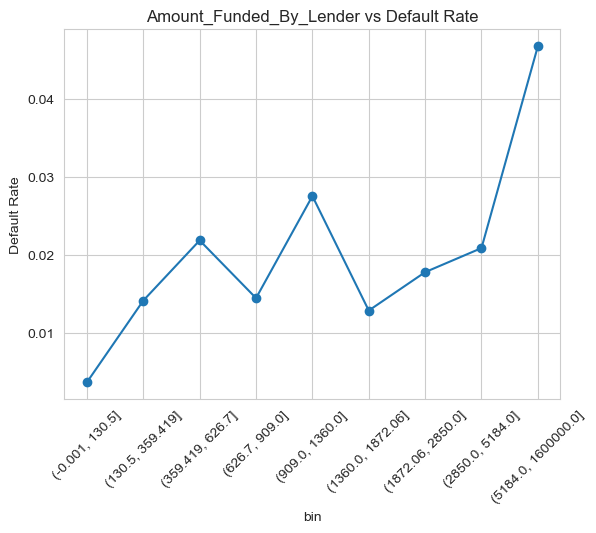

In [6]:
def plot_numeric_target(df, col):
    df["bin"] = pd.qcut(df[col], q=10, duplicates="drop")
    
    stats = df.groupby("bin")["target"].mean()
    
    plt.figure()
    stats.plot(marker="o")
    plt.title(f"{col} vs Default Rate")
    plt.ylabel("Default Rate")
    plt.xticks(rotation=45)
    plt.show()


for col in ["Total_Amount", "duration", "Amount_Funded_By_Lender"]:
    plot_numeric_target(train.copy(), col)

**TOTAL AMOUNT vs DEFAULT**

+ Increasing trend
+ Large loans → higher risk
+ Risk increases with exposure

BUT:

+ Relationship is non-linear
+ Slight instability in mid ranges

Feature strategy:
1. Log transform:
    + log_amount = log1p(Total_Amount)
2. Create:
    + repayment_ratio = Total_Amount_to_Repay / Total_Amount

**DURATION vs DEFAULT**
+ Strong upward trend
+ Longer duration → higher default
+ VERY STRONG RISK DRIVER
+ Meaning: Longer loans = more uncertainty... Time risk

Feature engineering:
+ duration_bucket
+ is_long_term = duration > threshold

**AMOUNT FUNDED BY LENDER**
+ Increasing trend
+ Higher funding → higher risk
+ This reflects: Exposure level, Possibly borrower profile

+ Important:

    + This is correlated with Total_Amount

+ Strategy:

    + Keep both but: Let tree models handle interaction, Or create ratios

**5. NON-LINEAR RELATIONSHIPS**

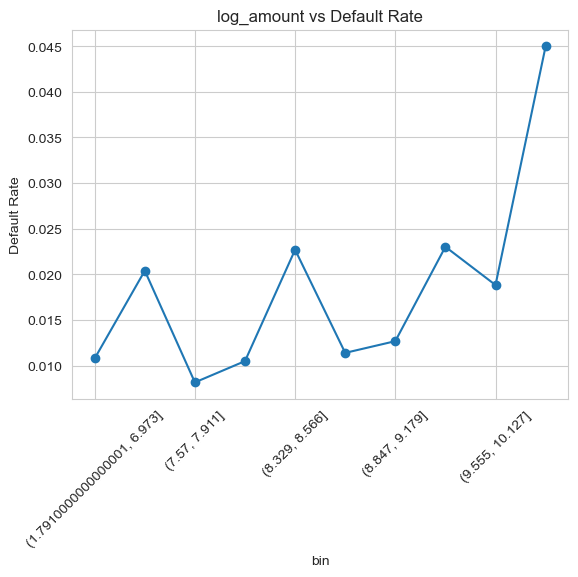

In [7]:
train["log_amount"] = np.log1p(train["Total_Amount"])

plot_numeric_target(train.copy(), "log_amount")


+ Smoother curve after log

+ Confirms:

    + Raw amount is skewed
    
    + Log transform is better

**6. INTERACTION EFFECTS**

6.1 Amount × Duration

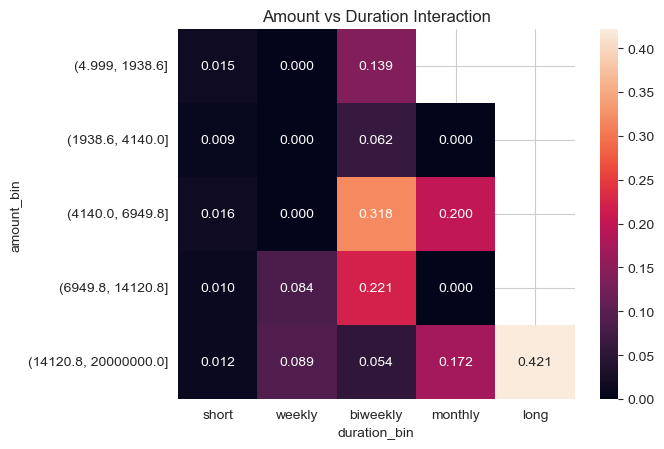

In [9]:
# Amount bins
train["amount_bin"] = pd.qcut(train["Total_Amount"], q=5, duplicates="drop")

# Duration bins (domain-driven)
train["duration_bin"] = pd.cut(
    train["duration"],
    bins=[0, 7, 14, 30, 90, 2000],
    labels=["short", "weekly", "biweekly", "monthly", "long"]
)

# Interaction
interaction = train.groupby(["amount_bin", "duration_bin"])["target"].mean().unstack()

plt.figure()
sns.heatmap(interaction, annot=True, fmt=".3f")
plt.title("Amount vs Duration Interaction")
plt.show()

+ High risk when:
    + Large amount + long duration
    + Medium amount + biweekly (unexpected spike)
+ Interpretation:
    + THIS IS GOLD: Single features are not enough — interaction matters.

+ Feature ideas:
    + amount_duration_ratio = Total_Amount / duration
    + high_risk_flag = (large_amount & long_duration)

6.2 New vs Repeat × Amount

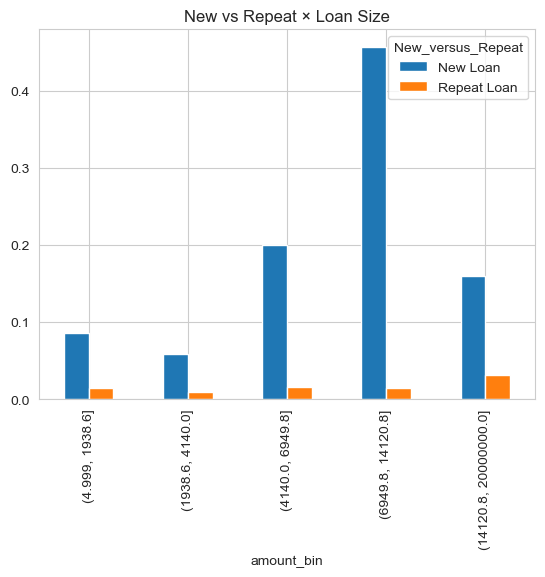

In [10]:
interaction = train.groupby(["New_versus_Repeat", "amount_bin"])["target"].mean().unstack()

interaction.T.plot(kind="bar")
plt.title("New vs Repeat × Loan Size")
plt.show()

+ New customers + large loans → extremely high default
+ Repeat customers → stable
+ Interpretation: This is our strongest interaction
+ Feature: new_large_loan = (is_new_customer == 1) & (Total_Amount > threshold)

**7. CUSTOMER-LEVEL BEHAVIOR**

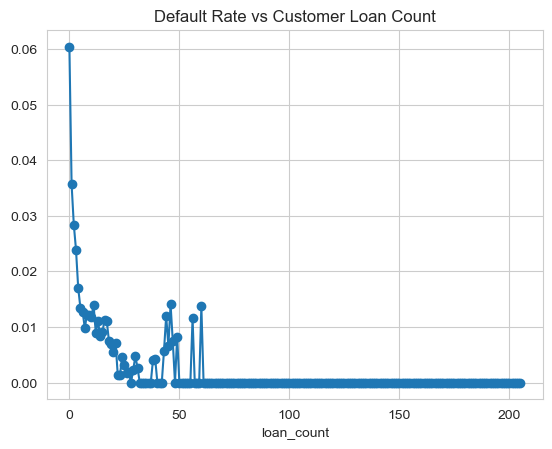

In [11]:
train_sorted = train.sort_values("disbursement_date")

train_sorted["past_defaults"] = (
    train_sorted.groupby("customer_id")["target"]
    .cumsum()
    .shift()
)

train_sorted["loan_count"] = train_sorted.groupby("customer_id").cumcount()

stats = train_sorted.groupby("loan_count")["target"].mean()

plt.figure()
stats.plot(marker="o")
plt.title("Default Rate vs Customer Loan Count")
plt.show()

+ Default rate drops sharply with loan count
+ High risk at first loans
+ Interpretation:
    + Experience reduces risk
    + This must be time-aware

+ Features:
    + loan_count
    + past_defaults
    + customer_default_rate

(using only past data)

**8. TEMPORAL ANALYSIS**

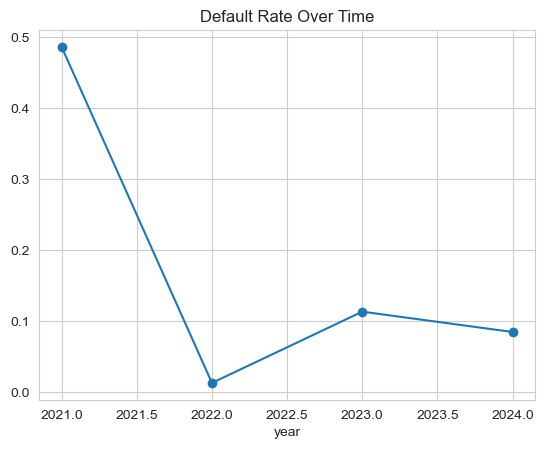

In [12]:
train["year"] = train["disbursement_date"].dt.year
train["month"] = train["disbursement_date"].dt.month

year_stats = train.groupby("year")["target"].mean()

plt.figure()
year_stats.plot(marker="o")
plt.title("Default Rate Over Time")
plt.show()

+ 2021 extremely high (~48%) → low sample size
+ 2022 very low (~1%)
+ 2023–2024 moderate
+ Interpretation:
    + Temporal instability
+ Risk:
    + Model may overfit to 2022
+ Strategy:
    + Use time features carefully
+ Possibly:
    + is_recent = year >= 2023

**9. TRAIN VS TEST SHIFT**

In [13]:
def compare_distribution(train, test, col):
    print(f"\n{col}")
    print("Train mean:", train[col].mean())
    print("Test mean:", test[col].mean())


for col in ["Total_Amount", "duration"]:
    compare_distribution(train, test, col)


Total_Amount
Train mean: 14592.70483322166
Test mean: 15366.443869527804

duration
Train mean: 8.503568619454073
Test mean: 13.682209314832741


+ Major shift in duration
+ Risk: Model trained on short loans → tested on longer loans

+ Strategy:
    + Avoid overfitting to short durations
    + Use robust models (tree-based)
    + Normalize / bucket duration

**10. ECONOMIC SIGNAL EXPLORATION**

In [14]:
print("Economic indicators:")
display(econ["Indicator"].unique())

Economic indicators:


<StringArray>
[                    'Inflation, consumer prices (annual %)',
      'Official exchange rate (LCU per US$, period average)',
                                    'Real interest rate (%)',
              'Average precipitation in depth (mm per year)',
                                 'Deposit interest rate (%)',
                                 'Lending interest rate (%)',
 'Interest rate spread (lending rate minus deposit rate, %)',
               'Fossil fuel energy consumption (% of total)',
                                         'Unemployment rate']
Length: 9, dtype: str

+ 9 indicators available
+ Interpretation: Key for generalization (Kenya → Ghana)
+ Merge by: country + year

**11. FEATURE IMPORTANCE PROXY**

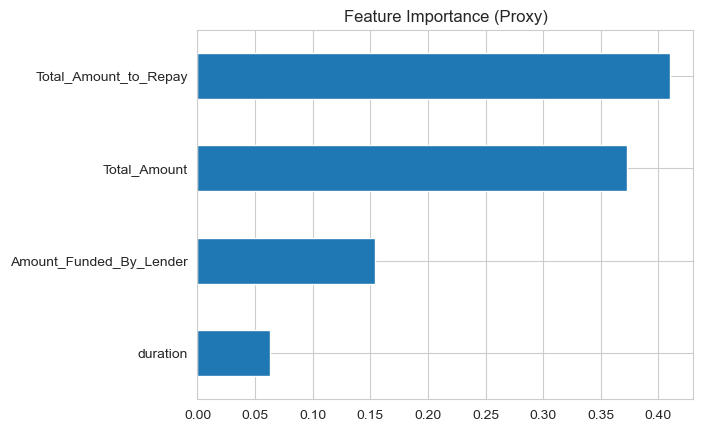

In [15]:
from sklearn.ensemble import RandomForestClassifier

features = [
    "Total_Amount",
    "Total_Amount_to_Repay",
    "duration",
    "Amount_Funded_By_Lender"
]

X = train[features]
y = train["target"]

model = RandomForestClassifier(n_estimators=50, random_state=42)
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance (Proxy)")
plt.show()

+ Total_Amount_to_Repay (~0.40)
+ Total_Amount (~0.37)
+ Amount_Funded (~0.15)
+ Duration (~0.06)
+ Important nuance:
    + Repayment > Amount → interest signal
    + Duration appears low → but interacts strongly
+ Warning: Tree importance ≠ true importance

**12. FINAL SECTION — FEATURE ENGINEERING BLUEPRINT**

In [16]:
print("""
=====================
FEATURE ENGINEERING BLUEPRINT
=====================

1. Customer Features:
   - past_defaults
   - loan_count
   - customer_default_rate

2. Financial Features:
   - log_total_amount
   - repayment_ratio
   - loan_pressure

3. Interaction Features:
   - amount × duration
   - new_vs_repeat × amount

4. Temporal Features:
   - year
   - month

5. Categorical Handling:
   - grouped loan_type

6. Distribution Robustness:
   - handle train/test shift

7. Economic Features:
   - merge by country + year
   - include missing indicators

""")


FEATURE ENGINEERING BLUEPRINT

1. Customer Features:
   - past_defaults
   - loan_count
   - customer_default_rate

2. Financial Features:
   - log_total_amount
   - repayment_ratio
   - loan_pressure

3. Interaction Features:
   - amount × duration
   - new_vs_repeat × amount

4. Temporal Features:
   - year
   - month

5. Categorical Handling:
   - grouped loan_type

6. Distribution Robustness:
   - handle train/test shift

7. Economic Features:
   - merge by country + year
   - include missing indicators




# 📊 Advanced EDA — Summary Report

## 1. 🎯 Objective

This analysis aimed to uncover meaningful patterns, relationships, and risks within the dataset to inform feature engineering, preprocessing, and modeling strategies for loan default prediction.

---

## 2. ⚠️ Target Imbalance

* Default rate: **~1.83%**
* Severe class imbalance

### Implications:

* Accuracy is not suitable
* F1 score must be optimized
* Requires class weighting and threshold tuning

---

## 3. 📊 Key Feature Insights

### 3.1 Loan Type

* Some categories show high default rates
* However, these are based on very small sample sizes

### Decision:

* Group rare categories to avoid overfitting

---

### 3.2 New vs Repeat Loan

* New loans: ~19.9% default
* Repeat loans: ~1.7% default

### Insight:

* Strongest individual predictor
* Captures borrower reliability

---

### 3.3 Loan Amount

* Larger loans → higher default risk
* Non-linear relationship observed

### Decision:

* Apply log transformation
* Create ratio-based features

---

### 3.4 Duration

* Strong positive relationship with default risk

### Insight:

* Longer loans are riskier

---

## 4. 🔥 Interaction Effects

### 4.1 Amount × Duration

* High risk for large, long-duration loans

### 4.2 New Customer × Loan Size

* New customers taking large loans are highest risk group

### Decision:

* Include interaction features

---

## 5. 🧠 Customer Behavior

* Default risk decreases with number of past loans
* Experienced borrowers are safer

### Decision:

* Engineer customer-level features:

  * Loan count
  * Past defaults
  * Historical default rate

---

## 6. 📅 Temporal Dynamics

* Significant variation across years
* 2022 dominates dataset

### Risk:

* Temporal bias

### Decision:

* Include time features cautiously

---

## 7. 🔄 Distribution Shift

* Test data has longer loan durations than training

### Risk:

* Model generalization issues

### Decision:

* Use robust features and avoid overfitting

---

## 8. 🌍 Economic Features

* Provide macro-level signals
* Useful for cross-country generalization

### Decision:

* Merge using country and year
* Handle missing values carefully

---

## 9. 🔬 Feature Importance Insights

* Financial variables dominate
* Duration has interaction-driven importance

---

## 10. 🚀 Feature Engineering Strategy

### Customer-Level Features

* Past defaults
* Loan count
* Default rate

### Financial Features

* Log loan amount
* Repayment ratio

### Interaction Features

* Amount × duration
* New vs repeat × amount

### Temporal Features

* Year, month

### Categorical Handling

* Group rare loan types

---

## 11. 🧠 Final Conclusion

The problem is best framed as a **behavioral credit risk modeling task**, where:

* Customer history
* Loan characteristics
* Interaction effects

are more predictive than individual features alone.

A robust modeling pipeline must therefore:

* Prevent leakage
* Capture temporal dynamics
* Incorporate behavioral signals
* Handle class imbalance effectively

---
